<a href="https://colab.research.google.com/github/batoolabualhayjaa33-droid/ML-final-project/blob/main/OnlineNewsPopularity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [ ]:
news_data = pd.read_csv("OnlineNewsPopularity.csv")

display(news_data.head())

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593.0
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711.0
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500.0
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200.0
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505.0


In [ ]:
news_data.columns = news_data.columns.str.strip()

In [ ]:
print(news_data.shape)

(17143, 61)


In [ ]:
print(news_data.columns)

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [ ]:
news_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17143 entries, 0 to 17142
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            17143 non-null  object 
 1   timedelta                      17143 non-null  float64
 2   n_tokens_title                 17143 non-null  float64
 3   n_tokens_content               17143 non-null  float64
 4   n_unique_tokens                17143 non-null  float64
 5   n_non_stop_words               17143 non-null  float64
 6   n_non_stop_unique_tokens       17143 non-null  float64
 7   num_hrefs                      17143 non-null  float64
 8   num_self_hrefs                 17143 non-null  float64
 9   num_imgs                       17143 non-null  float64
 10  num_videos                     17143 non-null  float64
 11  average_token_length           17143 non-null  float64
 12  num_keywords                   17143 non-null 

In [ ]:
display(news_data.describe())

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,17143.000000,17143.000000,17143.000000,17143.000000,17143.000000,17143.000000,17143.000000,17143.000000,17143.000000,17143.000000,...,17142.000000,17142.000000,17142.000000,17142.000000,17142.000000,17142.000000,17142.000000,17142.000000,17142.000000,17142.000000
mean,568.844485,9.877443,508.159249,0.557880,0.993058,0.701022,10.829143,3.486321,3.990083,1.219565,...,0.099126,0.779438,-0.258271,-0.500364,-0.113718,0.276343,0.081870,0.344503,0.154926,3445.068370
std,97.246631,1.977730,432.670423,0.116731,0.083029,0.118408,10.807753,4.122812,7.915765,4.233608,...,0.071644,0.222528,0.127478,0.280055,0.099749,0.323016,0.262713,0.188880,0.227415,13997.109192
min,398.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,4.000000
25%,484.000000,9.000000,230.000000,0.486132,1.000000,0.640891,5.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.325806,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,924.000000
50%,569.000000,10.000000,375.000000,0.557994,1.000000,0.705882,7.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.250000,-0.500000,-0.100000,0.100000,0.000000,0.500000,0.000000,1400.000000
75%,655.000000,11.000000,654.000000,0.630682,1.000000,0.772076,13.000000,4.000000,1.000000,1.000000,...,0.100000,1.000000,-0.183333,-0.300000,-0.050000,0.500000,0.166667,0.500000,0.250000,2800.000000
max,731.000000,18.000000,6336.000000,1.000000,1.000000,1.000000,171.000000,74.000000,99.000000,75.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


In [ ]:
missing_values = news_data.isnull().sum()

print(missing_values)

url                             0
timedelta                       0
n_tokens_title                  0
n_tokens_content                0
n_unique_tokens                 0
                               ..
title_subjectivity              1
title_sentiment_polarity        1
abs_title_subjectivity          1
abs_title_sentiment_polarity    1
shares                          1
Length: 61, dtype: int64


In [ ]:
duplicate_rows = news_data.duplicated().sum()

print(duplicate_rows)

0


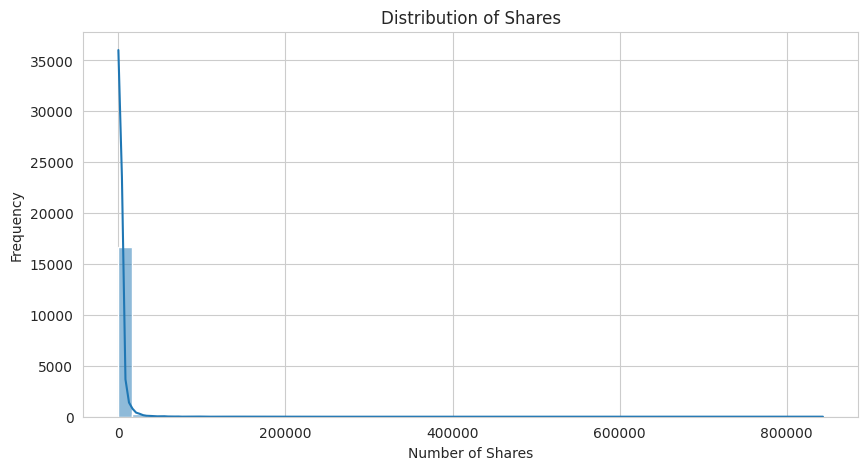

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))

sns.histplot(news_data['shares'], bins=50, kde=True)

plt.title("Distribution of Shares")
plt.xlabel("Number of Shares")
plt.ylabel("Frequency")

plt.show()

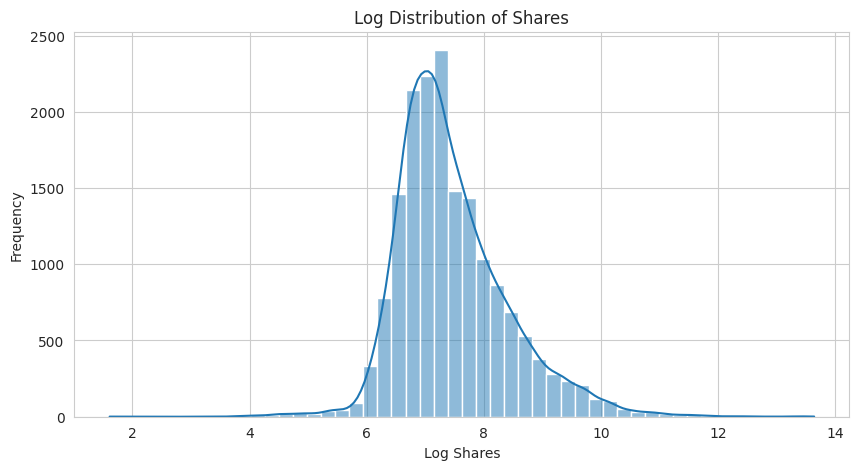

In [ ]:
news_data['log_shares'] = np.log1p(news_data['shares'])

plt.figure(figsize=(10,5))

sns.histplot(news_data['log_shares'], bins=50, kde=True)

plt.title("Log Distribution of Shares")
plt.xlabel("Log Shares")
plt.ylabel("Frequency")

plt.show()

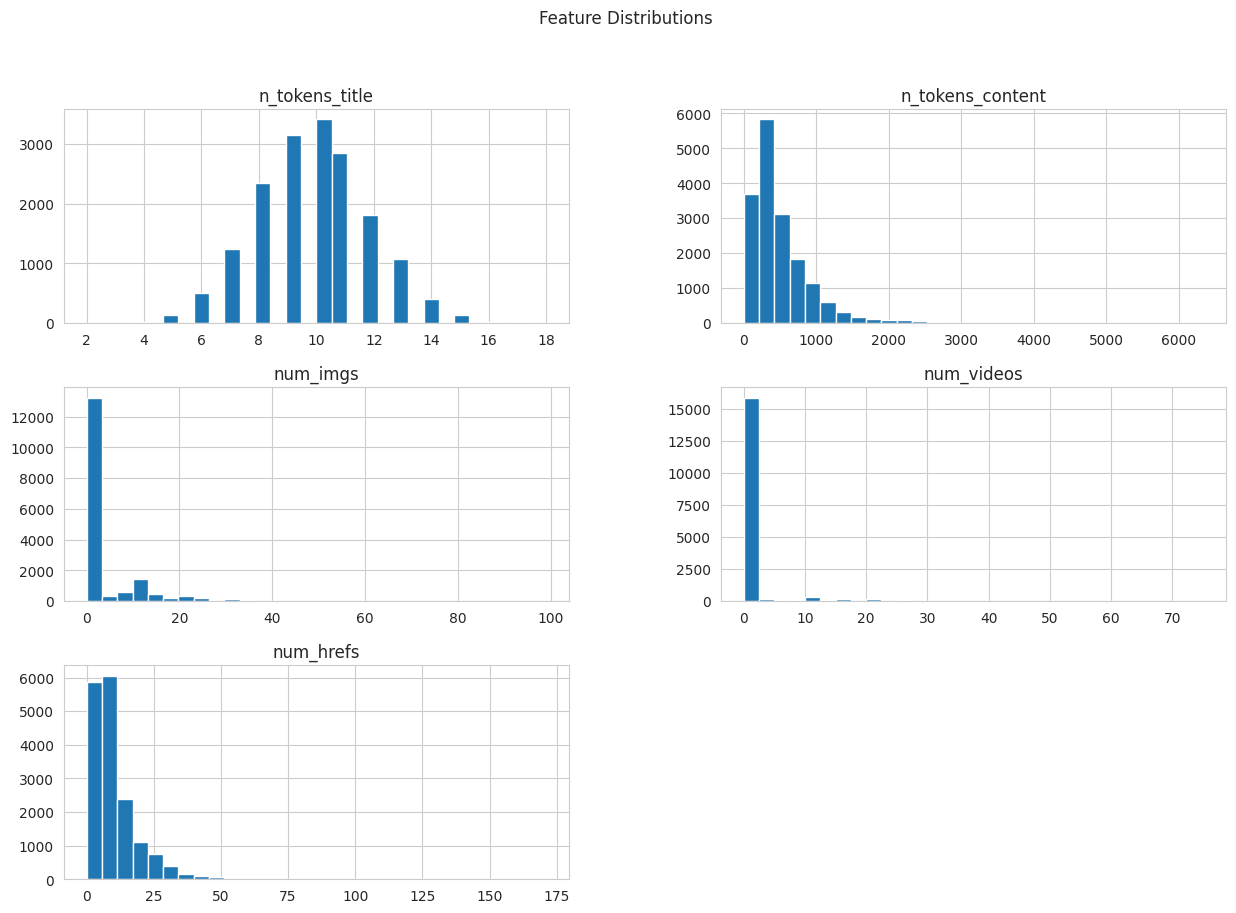

In [ ]:
important_features = [
    'n_tokens_title',
    'n_tokens_content',
    'num_imgs',
    'num_videos',
    'num_hrefs'
]

news_data[important_features].hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle("Feature Distributions")

plt.show()

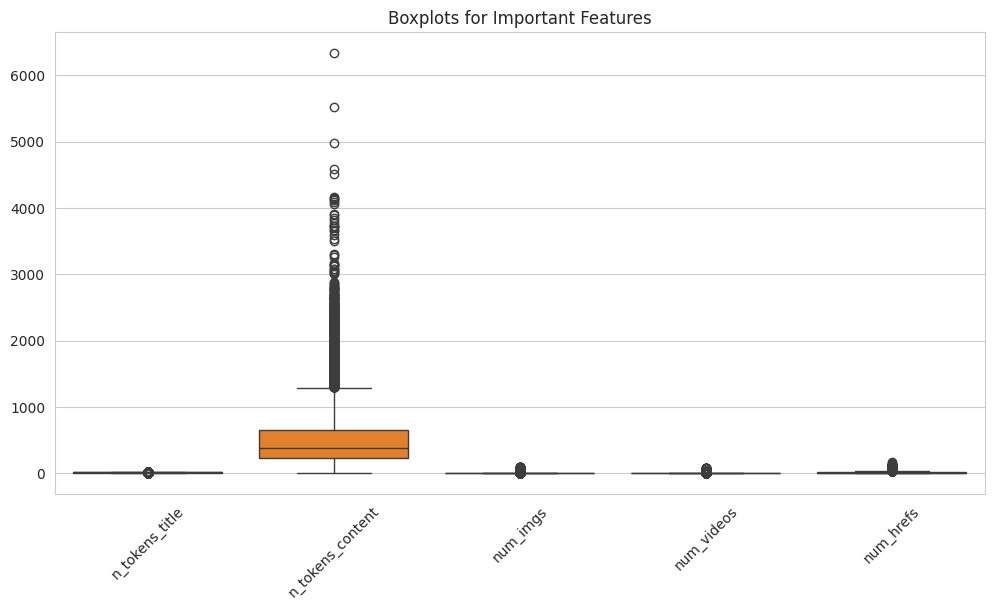

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=news_data[important_features])

plt.title("Boxplots for Important Features")

plt.xticks(rotation=45)

plt.show()

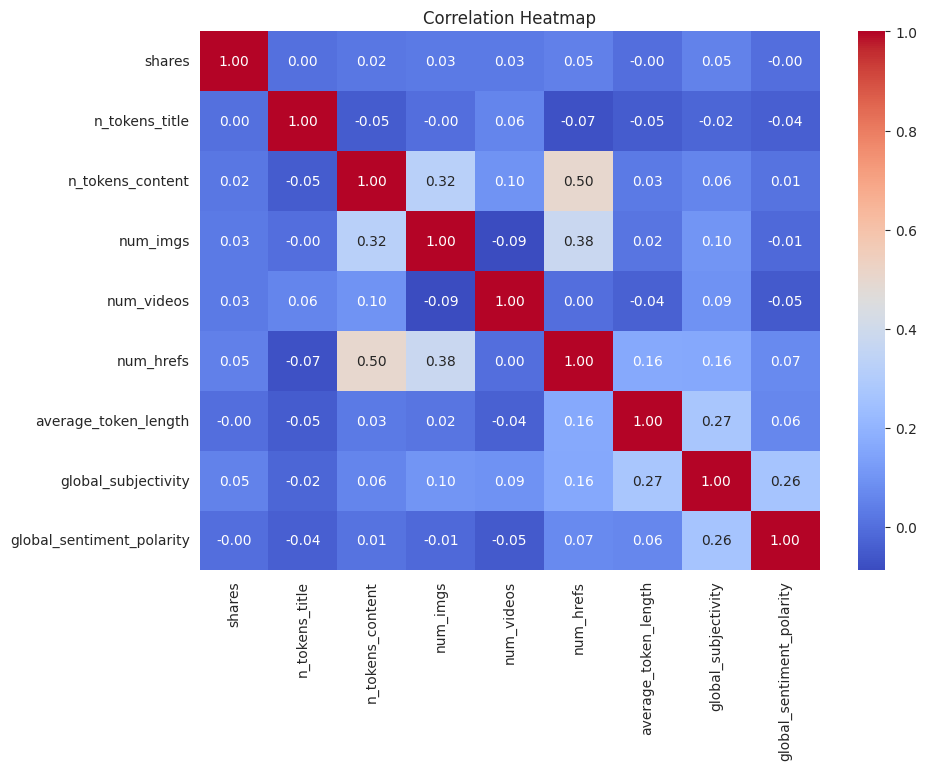

In [ ]:
selected_columns = [
    'shares',
    'n_tokens_title',
    'n_tokens_content',
    'num_imgs',
    'num_videos',
    'num_hrefs',
    'average_token_length',
    'global_subjectivity',
    'global_sentiment_polarity'
]

correlation_matrix = news_data[selected_columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

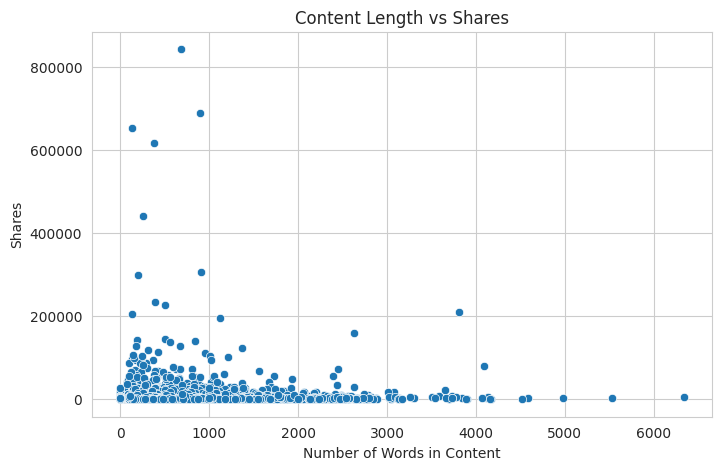

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=news_data['n_tokens_content'],
    y=news_data['shares']
)

plt.title("Content Length vs Shares")
plt.xlabel("Number of Words in Content")
plt.ylabel("Shares")

plt.show()

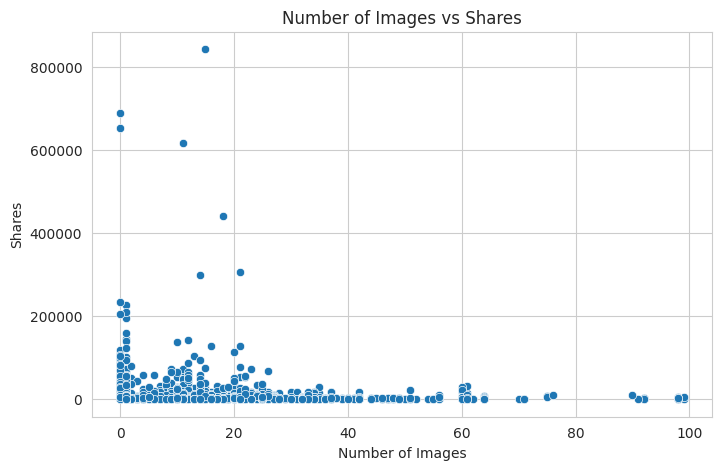

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=news_data['num_imgs'],
    y=news_data['shares']
)

plt.title("Number of Images vs Shares")
plt.xlabel("Number of Images")
plt.ylabel("Shares")

plt.show()

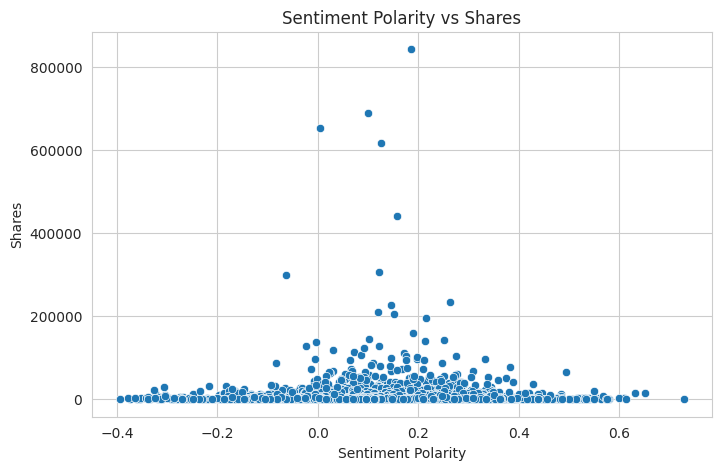

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=news_data['global_sentiment_polarity'],
    y=news_data['shares']
)

plt.title("Sentiment Polarity vs Shares")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Shares")

plt.show()

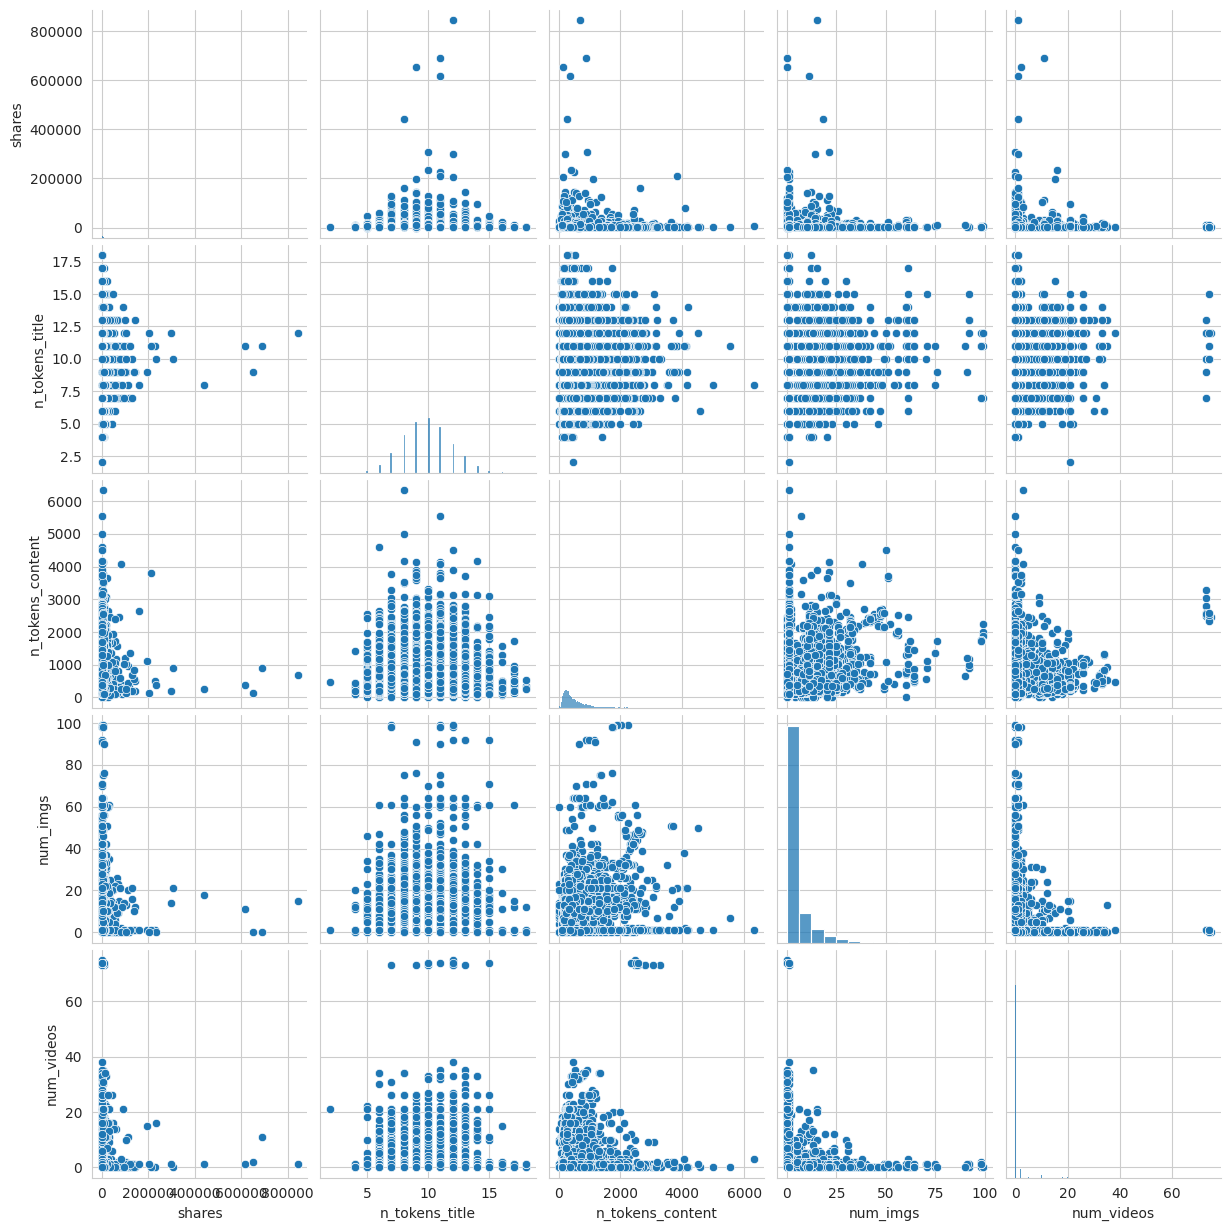

In [ ]:
pairplot_features = [
    'shares',
    'n_tokens_title',
    'n_tokens_content',
    'num_imgs',
    'num_videos'
]

sns.pairplot(news_data[pairplot_features])

plt.show()

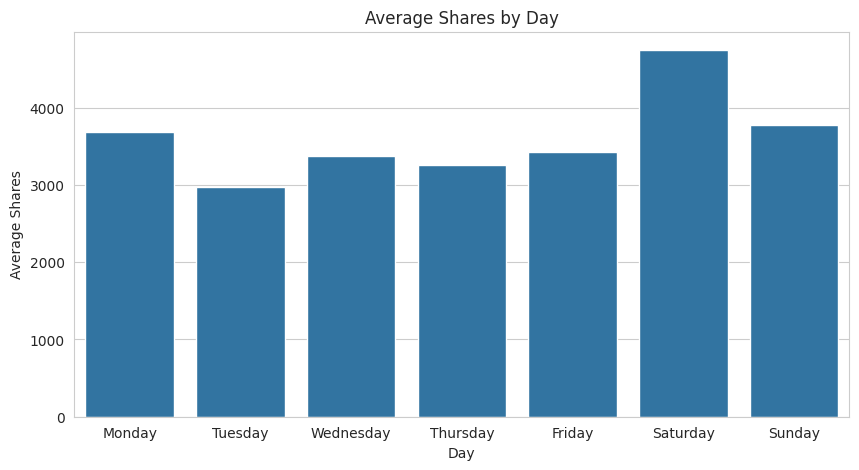

In [ ]:
weekday_columns = [
    'weekday_is_monday',
    'weekday_is_tuesday',
    'weekday_is_wednesday',
    'weekday_is_thursday',
    'weekday_is_friday',
    'weekday_is_saturday',
    'weekday_is_sunday'
]



weekday_shares = []

for day in weekday_columns:

    average_shares = news_data[news_data[day] == 1]['shares'].mean()

    weekday_shares.append(average_shares)



days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]



plt.figure(figsize=(10,5))

sns.barplot(
    x=days,
    y=weekday_shares
)

plt.title("Average Shares by Day")
plt.xlabel("Day")
plt.ylabel("Average Shares")

plt.show()



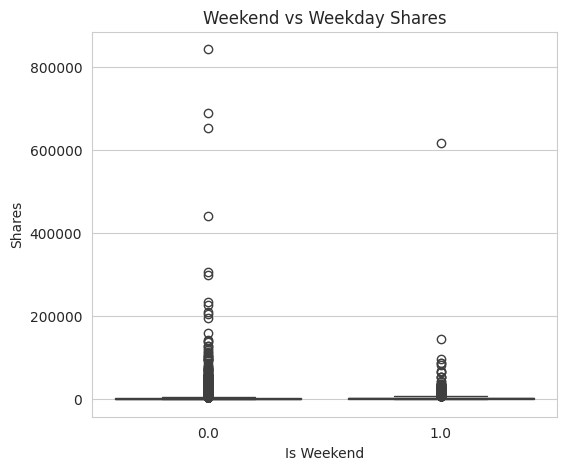

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x=news_data['is_weekend'],
    y=news_data['shares']
)

plt.title("Weekend vs Weekday Shares")
plt.xlabel("Is Weekend")
plt.ylabel("Shares")

plt.show()

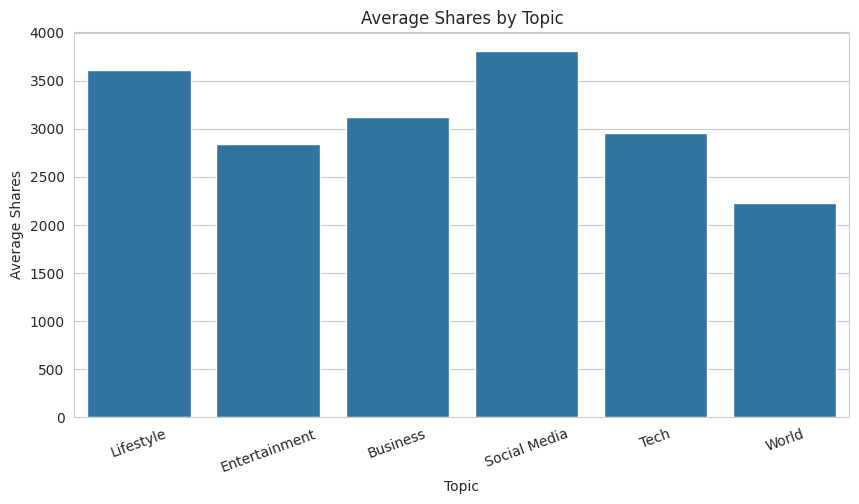

In [ ]:
topic_columns = [
    'data_channel_is_lifestyle',
    'data_channel_is_entertainment',
    'data_channel_is_bus',
    'data_channel_is_socmed',
    'data_channel_is_tech',
    'data_channel_is_world'
]

topic_names = [
    'Lifestyle',
    'Entertainment',
    'Business',
    'Social Media',
    'Tech',
    'World'
]

topic_average_shares = []

for topic in topic_columns:

    avg_shares = news_data[news_data[topic] == 1]['shares'].mean()

    topic_average_shares.append(avg_shares)


plt.figure(figsize=(10,5))

sns.barplot(
    x=topic_names,
    y=topic_average_shares
)

plt.title("Average Shares by Topic")
plt.xlabel("Topic")
plt.ylabel("Average Shares")

plt.xticks(rotation=20)

plt.show()

1917
866
8021
1247
1261


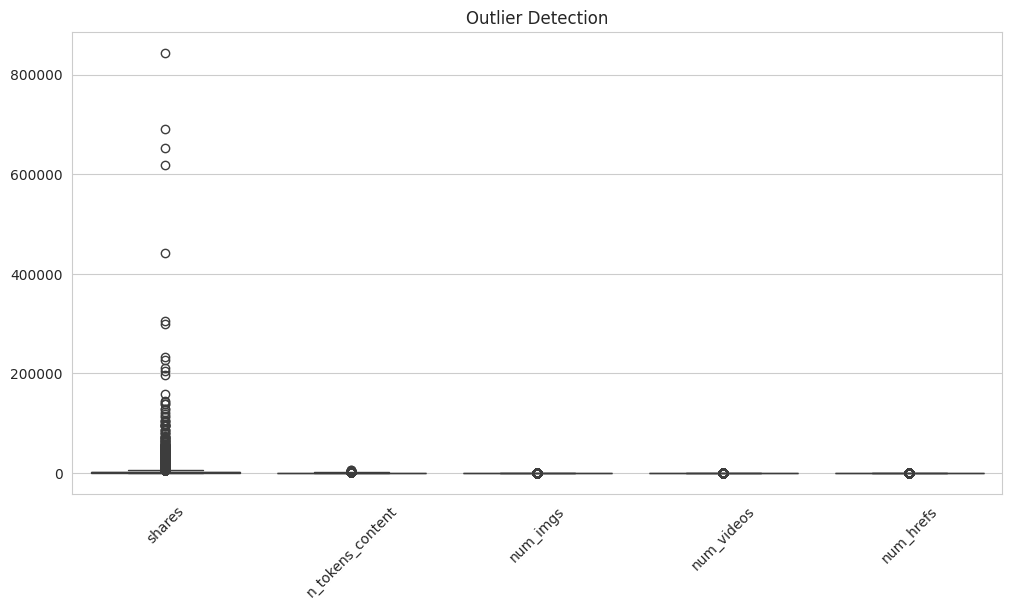

Outliers were clipped successfully.


In [ ]:

outlier_features = [
    'shares',
    'n_tokens_content',
    'num_imgs',
    'num_videos',
    'num_hrefs'
]



for column in outlier_features:

    Q1 = news_data[column].quantile(0.25)
    Q3 = news_data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = news_data[
        (news_data[column] < lower_bound) |
        (news_data[column] > upper_bound)
    ]


    print(outliers.shape[0])



plt.figure(figsize=(12,6))

sns.boxplot(data=news_data[outlier_features])

plt.title("Outlier Detection")

plt.xticks(rotation=45)

plt.show()



clipped_data = news_data.copy()

for column in outlier_features:

    Q1 = clipped_data[column].quantile(0.25)
    Q3 = clipped_data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clipped_data[column] = clipped_data[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )




In [ ]:

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)



scaling_data = news_data.drop(columns=['url'])



standard_scaler = StandardScaler()

standard_scaled_data = standard_scaler.fit_transform(scaling_data)

standard_scaled_data = pd.DataFrame(
    standard_scaled_data,
    columns=scaling_data.columns
)




Standard Scaling Completed


In [ ]:


minmax_scaler = MinMaxScaler()

minmax_scaled_data = minmax_scaler.fit_transform(scaling_data)

minmax_scaled_data = pd.DataFrame(
    minmax_scaled_data,
    columns=scaling_data.columns
)



Min-Max Scaling Completed


In [ ]:

robust_scaler = RobustScaler()

robust_scaled_data = robust_scaler.fit_transform(scaling_data)

robust_scaled_data = pd.DataFrame(
    robust_scaled_data,
    columns=scaling_data.columns
)



Robust Scaling Completed


In [ ]:
# Feature Engineering
# 1. Content Complexity Score
engineered_data = news_data.copy()
engineered_data['content_complexity'] = (
    engineered_data['average_token_length'] *
    engineered_data['n_tokens_content']
    )

In [ ]:
# 2. Keyword Density

engineered_data['keyword_density'] = (
    engineered_data['num_keywords'] /
    (engineered_data['n_tokens_content'] + 1)
)

In [ ]:
# 3. Media Score

engineered_data['media_score'] = (
    engineered_data['num_imgs'] +
    engineered_data['num_videos']
)

In [ ]:
# 4. Sentiment Engagement Score

engineered_data['sentiment_engagement'] = (
    engineered_data['global_sentiment_polarity'] *
    engineered_data['shares']
)

In [ ]:
# 5. Title Length Ratio

engineered_data['title_length_ratio'] = (
    engineered_data['n_tokens_title'] /
    (engineered_data['n_tokens_content'] + 1)
)

In [ ]:
# 6. Weekend Feature

engineered_data['weekend_article'] = (
    engineered_data['is_weekend']
)

In [ ]:
# 7. Log Transformations

engineered_data['log_shares'] = np.log1p(
    engineered_data['shares']
)

engineered_data['log_content_length'] = np.log1p(
    engineered_data['n_tokens_content']
)


In [ ]:
# Display New Features

new_features = [
    'content_complexity',
    'keyword_density',
    'media_score',
    'sentiment_engagement',
    'title_length_ratio',
    'weekend_article',
    'log_shares',
    'log_content_length'
]

print(engineered_data[new_features].head())

   content_complexity  keyword_density  media_score  sentiment_engagement  \
0              1025.0         0.022727          1.0             54.889256   
1              1253.0         0.015625          1.0            105.901894   
2               927.0         0.028302          1.0            485.000000   
3              2339.0         0.013158          1.0            120.845599   
4              5020.0         0.006524         20.0            141.906755   

   title_length_ratio  weekend_article  log_shares  log_content_length  
0            0.054545              0.0    6.386879            5.393628  
1            0.035156              0.0    6.568078            5.545177  
2            0.042453              0.0    7.313887            5.356586  
3            0.016917              0.0    7.090910            6.276643  
4            0.012116              0.0    6.226537            6.978214  


In [ ]:
# Classification Target Creation

df_class = engineered_data.copy()

threshold = df_class['shares'].median()

print("Median Threshold:", threshold)

df_class['popular'] = (df_class['shares'] > threshold).astype(int)

print(df_class['popular'].value_counts())

print(df_class['popular'].value_counts(normalize=True) * 100)

Median Threshold: 1400.0
popular
0    8573
1    8570
Name: count, dtype: int64
popular
0    50.00875
1    49.99125
Name: proportion, dtype: float64


In [ ]:

X = df_class.drop(columns=['shares', 'popular', 'url'])
y = df_class['popular']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print(y_train.value_counts(normalize=True))

Training set shape: (13714, 67)
Test set shape: (3429, 67)
popular
0    0.500073
1    0.499927
Name: proportion, dtype: float64


In [ ]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


In [ ]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, y_pred))

In [ ]:
# K-Nearest Neighbors Classifier


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

In [ ]:
y_pred_knn = knn_model.predict(X_test)

In [ ]:
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_knn))

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)



In [ ]:
X_train_svm = X_train.sample(8000, random_state=42)
y_train_svm = y_train.loc[X_train_svm.index]

In [ ]:

svm_linear = SVC(kernel='linear', probability=True, random_state=42)

svm_linear.fit(X_train_svm, y_train_svm)

y_pred_linear = svm_linear.predict(X_test)
y_prob_linear = svm_linear.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("F1:", f1_score(y_test, y_pred_linear))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_linear))

In [ ]:
cm = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)

svm_rbf.fit(X_train_svm, y_train_svm)

y_pred_rbf = svm_rbf.predict(X_test)
y_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("F1:", f1_score(y_test, y_pred_rbf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rbf))

In [ ]:

cm = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [ ]:
tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

In [ ]:

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]


In [ ]:

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tree))

In [ ]:

cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
importances = pd.Series(
    tree_model.feature_importances_,
    index=X_train.columns
)

importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))

importances.head(15).plot(kind='bar')

plt.title("Top Feature Importance - Decision Tree")

plt.show()

In [ ]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))

importances.head(15).plot(kind='bar')

plt.title("Top Feature Importance - Random Forest")

plt.show()

In [ ]:
# XGBoost Classifier

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [ ]:


xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

In [ ]:


y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

In [ ]:

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:

importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))

importances.head(15).plot(kind='bar')

plt.title("Top Feature Importance - XGBoost")

plt.show()

In [ ]:
# Model Comparison Table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),        # Logistic
        accuracy_score(y_test, y_pred_knn),     # KNN
        accuracy_score(y_test, y_pred_linear),  # SVM (linear)
        accuracy_score(y_test, y_pred_tree),    # Tree
        accuracy_score(y_test, y_pred_rf),      # RF
        accuracy_score(y_test, y_pred_xgb)      # XGBoost
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_linear),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results.sort_values(by="ROC-AUC", ascending=False)

In [ ]:
# ROC Curve Comparison

from sklearn.metrics import roc_curve

plt.figure(figsize=(10,7))

models = [
    ("LogReg", y_prob),
    ("KNN", y_prob_knn),
    ("SVM", y_prob_linear),
    ("Tree", y_prob_tree),
    ("RF", y_prob_rf),
    ("XGB", y_prob_xgb)
]

for name, prob in models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

In [ ]:
# Precision-Recall Curve

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10,7))

for name, prob in models:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    plt.plot(recall, precision, label=name)

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.show()

In [ ]:
# Confusion Matrix - Best Model (XGBoost)

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - XGBoost (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:

df_reg = engineered_data.copy()

df_reg = df_reg.drop(columns=['url'])

y_reg = df_reg['shares']

X_reg = df_reg.drop(columns=['shares'])

from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)


In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_reg = LinearRegression()

lin_reg.fit(X_train_r, y_train_r)

y_pred_lr = lin_reg.predict(X_test_r)



mae = mean_absolute_error(y_test_r, y_pred_lr)
mse = mean_squared_error(y_test_r, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_lr)

print("Linear Regression Results:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_r, y_train_r)

y_pred_ridge = ridge.predict(X_test_r)

print("\nRidge Regression R2:", r2_score(y_test_r, y_pred_ridge))

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train_r, y_train_r)

y_pred_lasso = lasso.predict(X_test_r)

print("\nLasso Regression R2:", r2_score(y_test_r, y_pred_lasso))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_r, y_train_r)

y_pred_rf_r = rf_reg.predict(X_test_r)

print("\nRandom Forest R2:", r2_score(y_test_r, y_pred_rf_r))

In [ ]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_reg.fit(X_train_r, y_train_r)

y_pred_xgb_r = xgb_reg.predict(X_test_r)

print("\nXGBoost R2:", r2_score(y_test_r, y_pred_xgb_r))

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(y_test_r, y_pred_xgb_r, alpha=0.3)

plt.xlabel("Actual Shares")
plt.ylabel("Predicted Shares")
plt.title("XGBoost: Actual vs Predicted")

plt.show()

In [ ]:
# Grid Search for XGBoost (Classification)

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3)
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params (Random Search):", random_search.best_params_)
print("Best Score:", random_search.best_score_)

In [ ]:
from sklearn.model_selection import cross_val_score

best_model = random_search.best_estimator_

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Mean CV Score:", cv_scores.mean())

In [ ]:
# SHAP Explainability for XGBoost

import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

In [ ]:

shap.summary_plot(shap_values, X_test)

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
shap.dependence_plot("num_imgs", shap_values, X_test)

In [ ]:
# Noise Injection Test

import numpy as np
from sklearn.metrics import accuracy_score

X_test_noise = X_test.copy()

noise = np.random.normal(0, 0.1, X_test_noise.shape)
X_test_noise = X_test_noise + noise

y_pred_noise_low = xgb_model.predict(X_test_noise)

print("Accuracy with Noise:", accuracy_score(y_test, y_pred_noise_low))

In [ ]:
# Medium noise
noise_med = np.random.normal(0, 0.3, X_test.shape)
X_test_med = X_test + noise_med

y_pred_med = xgb_model.predict(X_test_med)

print("Accuracy (Medium Noise):", accuracy_score(y_test, y_pred_med))


# High noise
noise_high = np.random.normal(0, 0.6, X_test.shape)
X_test_high = X_test + noise_high

y_pred_high = xgb_model.predict(X_test_high)

print("Accuracy (High Noise):", accuracy_score(y_test, y_pred_high))

In [ ]:
# Feature Removal Test

X_train_drop = X_train.drop(columns=['num_imgs', 'num_hrefs'])
X_test_drop = X_test.drop(columns=['num_imgs', 'num_hrefs'])

xgb_model.fit(X_train_drop, y_train)

y_pred_drop = xgb_model.predict(X_test_drop)

print("Accuracy after Feature Removal:", accuracy_score(y_test, y_pred_drop))

In [ ]:
# Reduced Data Experiment

sizes = [0.1, 0.3, 0.5, 1.0]
results = []

for s in sizes:
    X_small = X_train.sample(frac=s, random_state=42)
    y_small = y_train.loc[X_small.index]

    model = XGBClassifier(random_state=42, eval_metric='logloss')
    model.fit(X_small, y_small)

    y_pred_small = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_small)

    results.append((s, acc))

print("Data Size vs Accuracy:")
for r in results:
    print(r)

In [ ]:
# Outlier Stress Test

X_test_out = X_test.copy()

X_test_out.iloc[:50] = X_test_out.iloc[:50] * 10

y_pred_out = xgb_model.predict(X_test_out)

print("Accuracy with Outliers:", accuracy_score(y_test, y_pred_out))